# CatBoost Classifier for Customer Churn Prediction

## Objective

The objective of this notebook is to develop a CatBoost classifier for customer churn prediction and compare its performance with the previously developed Logistic Regression, Decision Tree, Random Forest and XGBoost models.

CatBoost is a gradient boosting algorithm specifically designed to handle categorical features efficiently while reducing prediction bias through Ordered Boosting.

This notebook includes:

- Baseline CatBoost Model
- Cross Validation
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Model Comparison
- Model Serialization

# Theory Behind CatBoost

## What is CatBoost?

CatBoost (Categorical Boosting) is a gradient boosting algorithm developed by Yandex.

It is designed specifically for datasets containing categorical variables.

Unlike many boosting algorithms that require extensive preprocessing, CatBoost can natively process categorical features.

---

## Why was CatBoost developed?

Traditional machine learning algorithms require categorical variables to be transformed into numerical representations before training.

Examples include:

- One-Hot Encoding
- Label Encoding
- Target Encoding

These approaches may increase dimensionality or introduce target leakage.

CatBoost addresses these issues using Ordered Boosting and specialized handling of categorical features.

---

## Ordered Boosting

Ordered Boosting prevents target leakage by ensuring that each observation is encoded using information only from previous observations.

This improves model generalization and reduces overfitting.

---

## Advantages

- Excellent performance on tabular data
- Handles categorical variables effectively
- Reduces target leakage
- Strong regularization
- Minimal preprocessing

---

## Limitations

- Slower than LightGBM in some scenarios
- Larger models
- More computationally demanding than Logistic Regression

---

## Business Relevance

Telecom customer datasets contain numerous categorical variables such as contract type, payment method and internet service.

CatBoost is particularly well suited for these types of problems.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from catboost import CatBoostClassifier

set_config(display="diagram")

In [2]:
df = pd.read_csv("../data/processed/telco_feature_engineered.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,AvgMonthlySpend,TotalServices,HasFamily,TenureGroup,SpendingGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,29.850000,1,0,New,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,55.573529,3,0,Established,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,54.075000,3,0,New,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,40.905556,3,0,Established,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,75.825000,1,0,New,Medium


In [3]:
X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

print(X.shape)
print(y.shape)

(7032, 24)
(7032,)


In [4]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "TotalServices"
]

binary_features = [
    "SeniorCitizen",
    "HasFamily"
]

nominal_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

ordinal_features = [
    "TenureGroup",
    "SpendingGroup"
]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "continuous",
            "passthrough",
            continuous_features
        ),

        (
            "binary",
            "passthrough",
            binary_features
        ),

        (
            "nominal",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["New", "Growing", "Established", "Loyal"],
                    ["Low", "Medium", "High"]
                ]
            ),
            ordinal_features
        )

    ]
)

In [7]:
baseline_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

In [8]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

In [9]:
pipeline.fit(
    X_train,
    y_train
)

print("Baseline CatBoost trained successfully.")

Baseline CatBoost trained successfully.


In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results = {}

for metric in metrics:

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=metric,
        n_jobs=-1
    )

    cv_results[metric] = scores

In [12]:
cv_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [cv_results[m].mean() for m in metrics],
    "Std": [cv_results[m].std() for m in metrics]
})

cv_summary["Metric"] = cv_summary["Metric"].str.upper()
cv_summary = cv_summary.round(4)

cv_summary

,Metric,Mean,Std
0,ACCURACY,0.7988,0.0052
1,PRECISION,0.6544,0.0104
2,RECALL,0.5144,0.0234
3,F1,0.5758,0.0167
4,ROC_AUC,0.8437,0.0064


In [13]:
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

Training Accuracy : 0.8832
Testing Accuracy  : 0.7896


In [14]:
param_grid = {
    "classifier__iterations": [100, 200],
    "classifier__depth": [4, 6, 8],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__l2_leaf_reg": [3, 5, 7]
}

In [15]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [16]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__depth': [4, 6, ...], 'classifier__iterations': [100, 200], 'classifier__l2_leaf_reg': [3, 5, ...], 'classifier__learning_rate': [0.03, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to k

In [17]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__depth': 4, 'classifier__iterations': 100, 'classifier__l2_leaf_reg': 3, 'classifier__learning_rate': 0.05}

Best ROC-AUC:
0.8508794447998576


In [18]:
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

test_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

test_summary["Score"] = test_summary["Score"].round(4)

test_summary

,Metric,Score
0,Accuracy,0.8017
1,Precision,0.6599
2,Recall,0.5241
3,F1 Score,0.5842
4,ROC AUC,0.8404


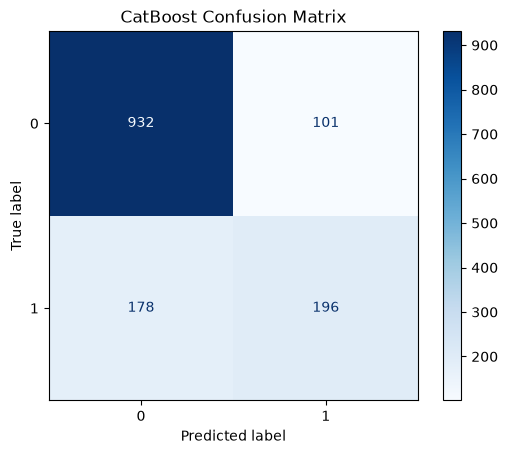

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("CatBoost Confusion Matrix")
plt.show()

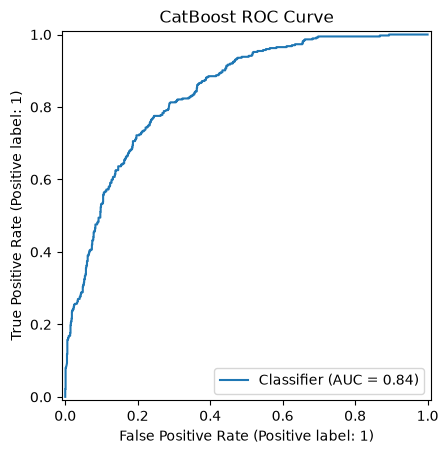

In [21]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("CatBoost ROC Curve")
plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [23]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = (
    best_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(15)

,Feature,Importance
39,nominal__Contract_Month-to-month,18.115269
0,continuous__tenure,13.987253
19,nominal__InternetService_Fiber optic,7.575630
41,nominal__Contract_Two year,6.698675
21,nominal__OnlineSecurity_No,6.185582
48,ordinal__TenureGroup,5.278760
3,continuous__AvgMonthlySpend,4.391808
49,ordinal__SpendingGroup,4.267961
30,nominal__TechSupport_No,4.216229
46,nominal__PaymentMethod_Electronic check,4.074221


In [24]:
joblib.dump(
    best_pipeline,
    "../models/catboost_pipeline.pkl"
)

print("CatBoost model saved!")

CatBoost model saved!


In [25]:
test_summary.to_csv(
    "../reports/catboost_results.csv",
    index=False
)

cv_summary.to_csv(
    "../reports/catboost_cv.csv",
    index=False
)

print("Reports saved!")

Reports saved!


# Conclusion

A CatBoost classifier was developed for customer churn prediction.

## Results

- Accuracy: **80.17%**
- Precision: **65.99%**
- Recall: **52.41%**
- F1 Score: **58.42%**
- ROC-AUC: **84.04%**

## Observations

- Hyperparameter tuning improved the cross-validation ROC-AUC from **0.8437** to **0.8509**.
- CatBoost achieved the highest precision among all models evaluated so far.
- The model also achieved the highest test accuracy, although the improvement over Logistic Regression was small.
- The model showed some overfitting, as the training accuracy (88.32%) exceeded the test accuracy (78.96%), but cross-validation and test ROC-AUC values remained close, indicating reasonable generalization.

Overall, CatBoost is a strong candidate for deployment and will be compared with LightGBM in the next notebook before selecting the final production model.